**RoBERTa**
 - same core architecture as BERT (a Transformer encoder stack). A masked language model that predicts masked tokens given context
 - more data, longer training, which allows it to 'know' its context (articles) to map it to one of four classes

# Imports and Loading Data

In [ ]:
!pip install -q -U keras keras-hub scikeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.21.1 requires keras-hub==0.21.1, but you have keras-hub 0.26.0 which is incompatible.


In [ ]:
import keras_hub # provides the pretrained tokenizer+backbone
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
from keras import layers

In [ ]:
from pathlib import Path
import os

def find_repo_root(start=None):
    start = Path(start or os.getcwd()).resolve()
    for p in [start, *start.parents]:
        if (p / "data" / "raw").exists():
            return p
    raise FileNotFoundError("Could not find repo root containing data/raw/")

REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "data" / "raw"

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"

print("Repo root:", REPO_ROOT)
print("Train path:", TRAIN_PATH)
print("Test path:", TEST_PATH)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
train_df = pd.read_csv(TRAIN_PATH).rename(columns={
    'Class Index': 'class',
    'Title': 'title',
    'Description': 'description'
})

In [ ]:
test_df = pd.read_csv(TEST_PATH).rename(columns={
    'Class Index': 'class',
    'Title': 'title',
    'Description': 'description'
})

# Building text predictor and label response

In [ ]:
train_text = (train_df.title + ' ' + train_df.description).values

In [ ]:
test_text = (test_df.title + ' ' + test_df.description).values

In [ ]:
y_train = (train_df['class']-1).values

In [ ]:
y_test = (test_df['class'] - 1).values
# sparse categorical loss expects int class ids starting at 0

# First Run Transformer Model

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    train_text, y_train, test_size=0.1, random_state=1, stratify=y_train
)

## Tokenizer and Packer

In [ ]:
tokenizer = keras_hub.models.Tokenizer.from_preset('roberta_base_en')
# tokenizer converts text -> subword token ids (by applying the RoBERTa pretrained vocab)
# vocab learned from pretained and fixed model, so no adapt() needed to ensure vocab learned from training data
backbone = keras_hub.models.Backbone.from_preset('roberta_base_en')
# converts token IDs -> contextual embeddings (vectors) that classifier head can learn from
# output will be a tensor of contextual embeddings (batch_size, seq_len, hidden_dim); thus, for every token position, a vector representation that encodes surrounding context is returned
# extracts meaningful features from text

100%|██████████| 445/445 [00:00<00:00, 1.15MB/s]


100%|██████████| 686/686 [00:00<00:00, 1.67MB/s]


100%|██████████| 0.99M/0.99M [00:00<00:00, 1.71MB/s]


100%|██████████| 446k/446k [00:00<00:00, 997kB/s] 


100%|██████████| 474M/474M [00:15<00:00, 31.8MB/s]


In [ ]:
MAX_LEN = 128 # if article text length is shorter than MAX_LEN, it gets padded roberta default pad values. else, truncated.
# every article becomes shape (256,). Wanting to see if improves performance (not cut off useful text)

# switched back to 128 because would have taken ~ an hour and a half to train 1 epoch


In [ ]:
packer = keras_hub.layers.StartEndPacker(
    sequence_length=MAX_LEN, # takes token IDs of sequence_length
    start_value=tokenizer.start_token_id, # adds start token at the beginning.
    end_value=tokenizer.end_token_id, # adds end token at end
    pad_value=tokenizer.pad_token_id, # pad token ids if length of article text < than MAX_LEN
    return_padding_mask=True # builds padding mask of 1 for real tokens, else 0
)

 - start/end tokens given consisten boundary signals. Also enable 'use first token's embedding as summary vector embedding (CLS-like)
 - padding+masks necessary because want fixed-size tensors per batch.
    - Padding introduces fake tokens - mask tells attention not to learn from them.

# Preprocessing

In [ ]:
def preprocess(text, label):
  token_ids = tokenizer(text)

  # packer(...) -> fixed [max_len] token_ids + padding_mask
  token_ids, padding_mask = packer(token_ids)

  # return dict matchin backbones expected input requirements
  return {'token_ids': token_ids, 'padding_mask': padding_mask}, label

## Building tensorflow datasets

In [ ]:
BATCH_SIZE = 32

In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
test_dataset = tf.data.Dataset.from_tensor_slices((test_text, y_test))

In [ ]:
train_dataset = (train_dataset.shuffle(20_000 # model randomly samples from buffer to feed batches to model (buffer of size <--). Helps ensure model doesn't patterns in batches e.g., World, World, World, World, .... Breaks order structure
                                       ).batch(BATCH_SIZE # enhances GPU efficiency for weight updates during backpropagation
                                               ).map(preprocess, num_parallel_calls=tf.data.AUTOTUNE #tokenization and packing happens concurrently
                                                     ).prefetch(tf.data.AUTOTUNE)) # pipelines batching working while GPU trains model

In [ ]:
val_dataset = (val_dataset.batch(BATCH_SIZE).map(preprocess,
                                                 num_parallel_calls=tf.data.AUTOTUNE
                                                 ).prefetch(tf.data.AUTOTUNE))

In [ ]:
test_dataset = (test_dataset.batch(
    BATCH_SIZE
).map(preprocess, num_parallel_calls=tf.data.AUTOTUNE
      ).prefetch(tf.data.AUTOTUNE))

# Building Classifier Model (Transformer + head)

In [ ]:
def build_transformer_classifier(
    preset='roberta_base_en',
    max_len=MAX_LEN,
    num_classes=4,
    dropout=0.1,
    dense_units=768,
    lr=3e-5,
    train_backbone=False, # fine-tuning weights
):
  tokenizer = keras_hub.models.Tokenizer.from_preset(preset)
  backbone = keras_hub.models.Backbone.from_preset(preset)

  backbone.trainable = train_backbone

  inputs = backbone.input # expects {'token_ids', 'padding_mask'}
  x = backbone(inputs) # [batch_size, seq_len, hidden_dim]. provides contextual embeddings for every token in sequence
  x = x[:, 0, :] # CLS token representation (RoBERTa uses first token)
  x = layers.Dropout(dropout)(x)
  x = layers.Dense(dense_units, activation='relu')(x)
  x = layers.Dropout(dropout)(x)
  outputs = layers.Dense(num_classes, activation='softmax')(x)

  model = keras.Model(inputs, outputs)

  model.compile(
      optimizer=keras.optimizers.Adam(lr),
      loss='sparse_categorical_crossentropy',
      metrics=['accuracy'],
  )

  return model

# Training with early stopping

In [ ]:
model = build_transformer_classifier()


In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True,
)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5,
    callbacks=[early_stopping]
)

Epoch 1/5
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 2948s 851ms/step - accuracy: 0.9227 - loss: 0.2256 - val_accuracy: 0.9401 - val_loss: 0.1754
Epoch 2/5
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 2895s 857ms/step - accuracy: 0.9468 - loss: 0.1552 - val_accuracy: 0.9398 - val_loss: 0.1788
Epoch 3/5
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 2899s 859ms/step - accuracy: 0.9570 - loss: 0.1237 - val_accuracy: 0.9302 - val_loss: 0.2238


Took roughly 45 minutes to train each epoch. Thus why not doing a comparison model in which I unfreeze and train deep layer weights nor doing gridsearch cross validation

# Performance

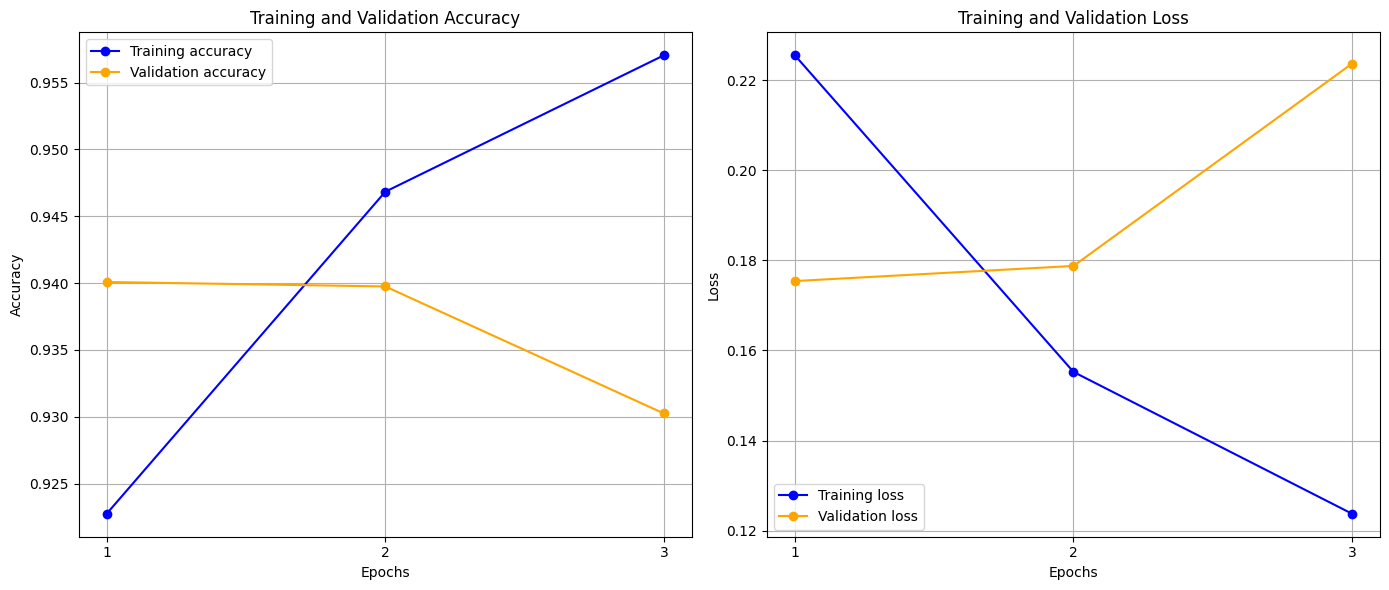

In [ ]:
import matplotlib.pyplot as plt

# Ensure the 'history' object is available from your model training
if 'history' not in locals():
    print("Error: 'history' object not found. Please run the model training cell first.")
else:
    history_dict = history.history

    # Get accuracy and loss values
    acc = history_dict.get('accuracy')
    val_acc = history_dict.get('val_accuracy')
    loss = history_dict.get('loss')
    val_loss = history_dict.get('val_loss')

    if acc is None or val_acc is None or loss is None or val_loss is None:
        print("Error: 'accuracy', 'val_accuracy', 'loss', or 'val_loss' not found in history.history.")
    else:
        epochs = range(1, len(acc) + 1)

        plt.figure(figsize=(14, 6))

        # Plot training and validation accuracy
        plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
        plt.plot(epochs, acc, 'o-', color='blue', label='Training accuracy')
        plt.plot(epochs, val_acc, 'o-', color='orange', label='Validation accuracy')
        plt.title('Training and Validation Accuracy')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True)
        plt.xticks(epochs) # Set x-axis ticks to integers

        # Plot training and validation loss
        plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
        plt.plot(epochs, loss, 'o-', color='blue', label='Training loss')
        plt.plot(epochs, val_loss, 'o-', color='orange', label='Validation loss')
        plt.title('Training and Validation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.xticks(epochs) # Set x-axis ticks to integers

        plt.tight_layout()
        plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

238/238 ━━━━━━━━━━━━━━━━━━━━ 62s 256ms/step - accuracy: 0.9400 - loss: 0.1795
Test Loss: 0.17952200770378113, Test Accuracy: 0.9399999976158142


238/238 ━━━━━━━━━━━━━━━━━━━━ 64s 264ms/step


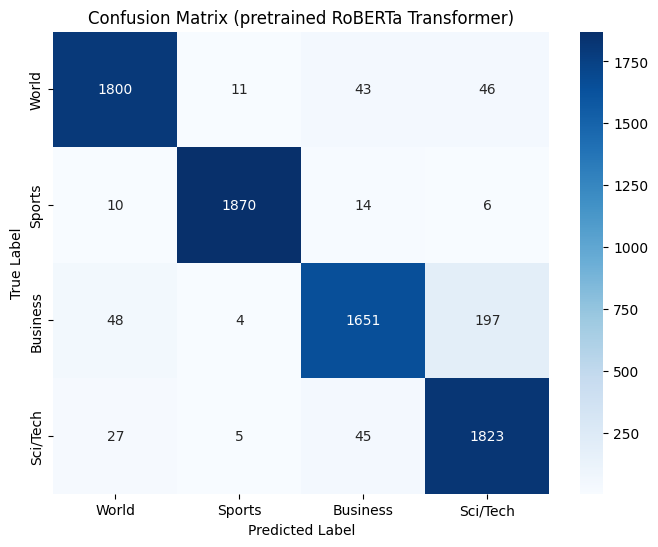

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Getting predictions from the model on the test dataset
# model.predict returns probabilities, so we need to get the class with the highest probability
y_pred_probabilities = model.predict(test_dataset)
y_pred = np.argmax(y_pred_probabilities, axis=1)

# Ensuring y_test is a flat array
y_true = y_test.flatten()


cm = confusion_matrix(y_true, y_pred)


class_labels = ['World', 'Sports', 'Business', 'Sci/Tech']

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (pretrained RoBERTa Transformer)')
plt.show()